**Семинар 1**.
   
* Прочесть данные из файла датасета DataR_CH1_run136_6.csv
* визуализировать события,
* провести предварительный визуальный анализ,
* установить форму сигналов.

Дать определение следующих понятий:
плазма, ион, дейтерий, протон, нейтрон, электрон, термоядерная реакция, АЦП.


In [ ]:
from google.colab import files
files.upload()

Saving DataR_CH1_run136_6.csv to DataR_CH1_run136_6.csv


{'DataR_CH1_run136_6.csv': b'BOARD;CHANNEL;TIMETAG;ENERGY;ENERGYSHORT;FLAGS;SAMPLES\n0;1;115320295667;210;149;0x4000;15378;15372;15383;15382;15376;15379;15381;15380;15375;15382;15386;15384;15380;15381;15384;15378;15378;15383;15381;15383;15375;15385;15375;15380;15374;15378;15382;15374;15379;15390;15379;15381;15383;15379;15389;15377;15371;15377;15381;15377;15378;15381;15388;15384;15386;15379;15383;15382;15382;15371;15380;15379;15382;15384;15381;15371;15376;15381;15381;15382;15374;15380;15383;15385;15380;15381;15381;15382;15382;15385;15376;15378;15381;15386;15385;15380;15378;15385;15380;15379;15380;15377;15375;15381;15381;15390;15386;15380;15371;15383;15379;15382;15376;15373;15387;15381;15381;15377;15354;15310;15033;14558;14464;14326;14263;14433;14513;14729;14877;14910;14908;14883;15062;15141;15138;15242;15213;15247;15273;15263;15266;15297;15273;15270;15298;15299;15327;15322;15320;15343;15350;15340;15321;15328;15346;15316;15333;15347;15350;15339;15367;15368;15369;15360;15336;15372;15374;1

In [ ]:
# загрузка необходимых библиотек
import numpy as np
from numpy import random
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# загрузка данных
df_src = 'DataR_CH1_run136_6.csv'
df = pd.read_csv(df_src, sep=';', header = None , skiprows=1)
PSD=df[4]/df[3]
df = df.drop([0,1,2,3,4,5],axis=1)
df.columns = list(range(df.shape[1]))
df.head()

,0,1,2,3,4,5,6,7,8,9,...,486,487,488,489,490,491,492,493,494,495
0,15378,15372,15383,15382,15376,15379,15381,15380,15375,15382,...,15380,15380,15372,15373,15383,15376,15383,15379,15387,15383
1,15382,15380,15375,15378,15386,15380,15378,15384,15386,15383,...,15383,15385,15385,15380,15382,15380,15378,15381,15379,15383
2,15388,15378,15373,15379,15391,15389,15380,15382,15378,15376,...,15376,15380,15375,15358,15349,15369,15374,15370,15364,15379
3,15378,15383,15378,15377,15389,15384,15376,15378,15371,15386,...,15379,15377,15369,15374,15375,15369,15359,15357,15376,15370
4,15383,15379,15380,15381,15381,15378,15378,15386,15378,15377,...,15391,15383,15391,15372,15390,15385,15386,15377,15387,15376


In [ ]:
df.shape



(2000, 496)


Построим графики всех сигналов из файла данных

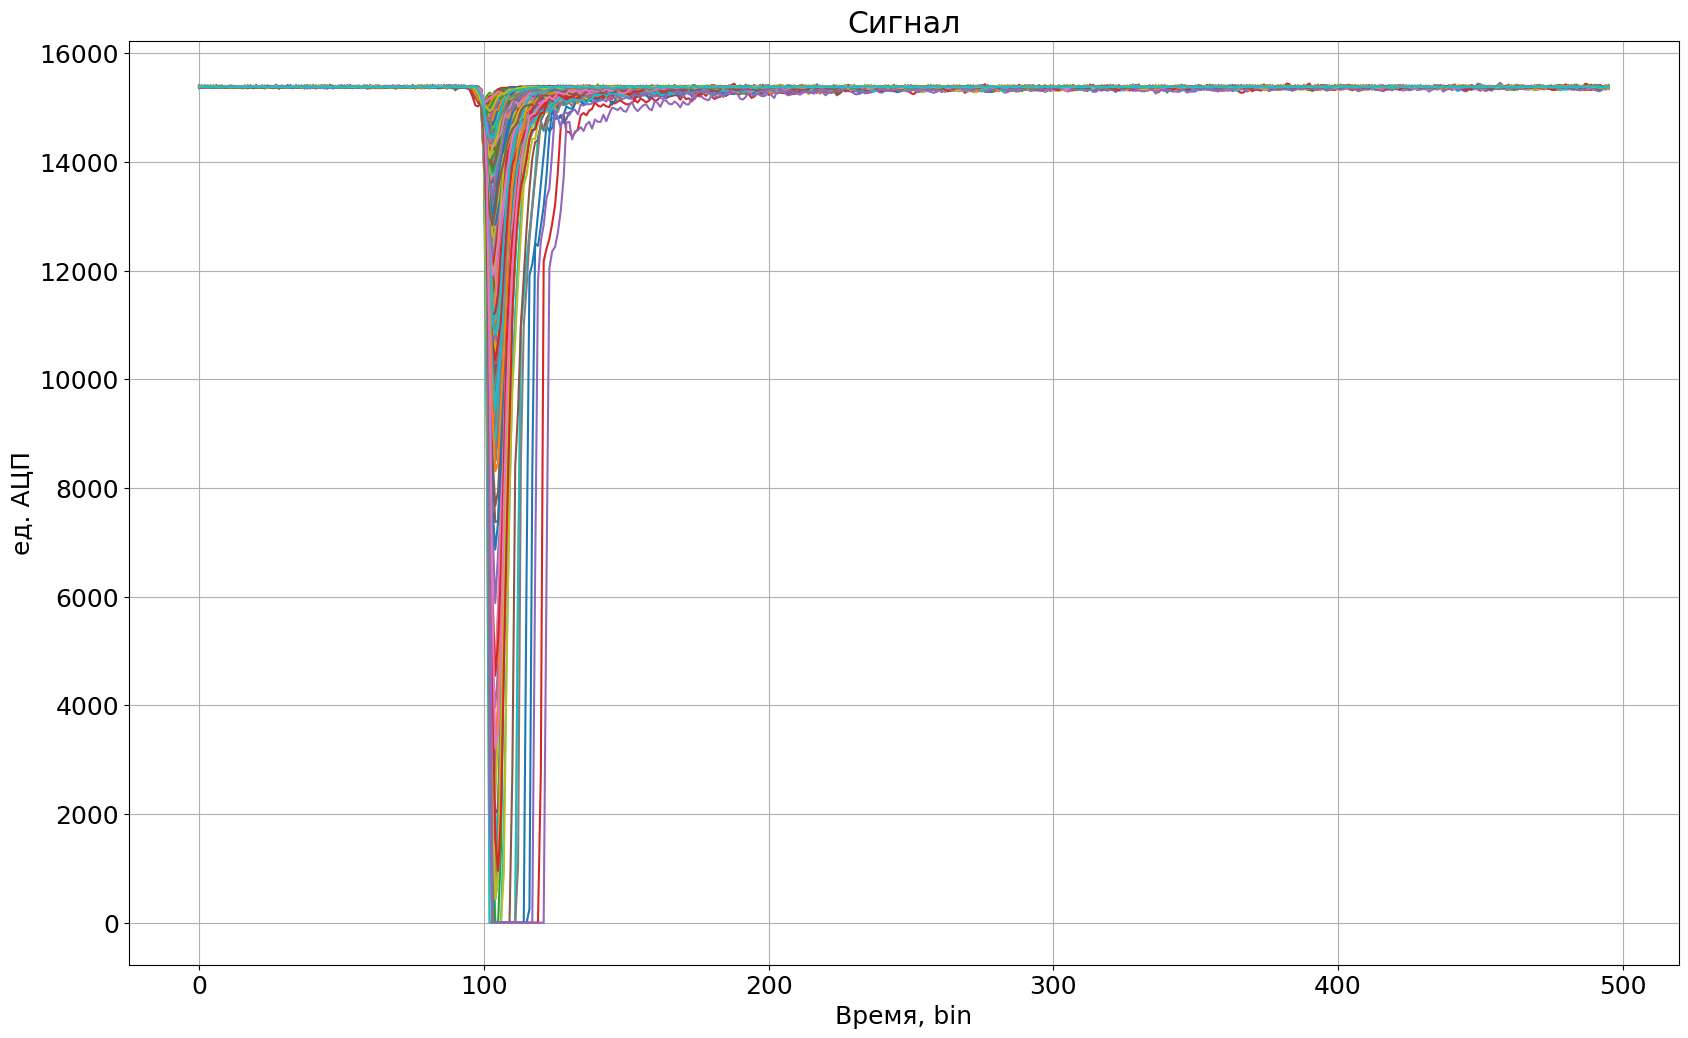

In [ ]:
np.random.seed(10)
N=random.randint(0,df.shape[0],500)
fs=18
plt.rcParams.update({'font.size': fs,'figure.figsize': (20, 12)})
ax = df.T[N].plot(legend=None)
ax.set_xlabel("Время, bin")
ax.set_ylabel("ед. АЦП")
ax.set_title('Сигнал')
ax.grid()

Text(0.5, 1.0, 'Сигнал')

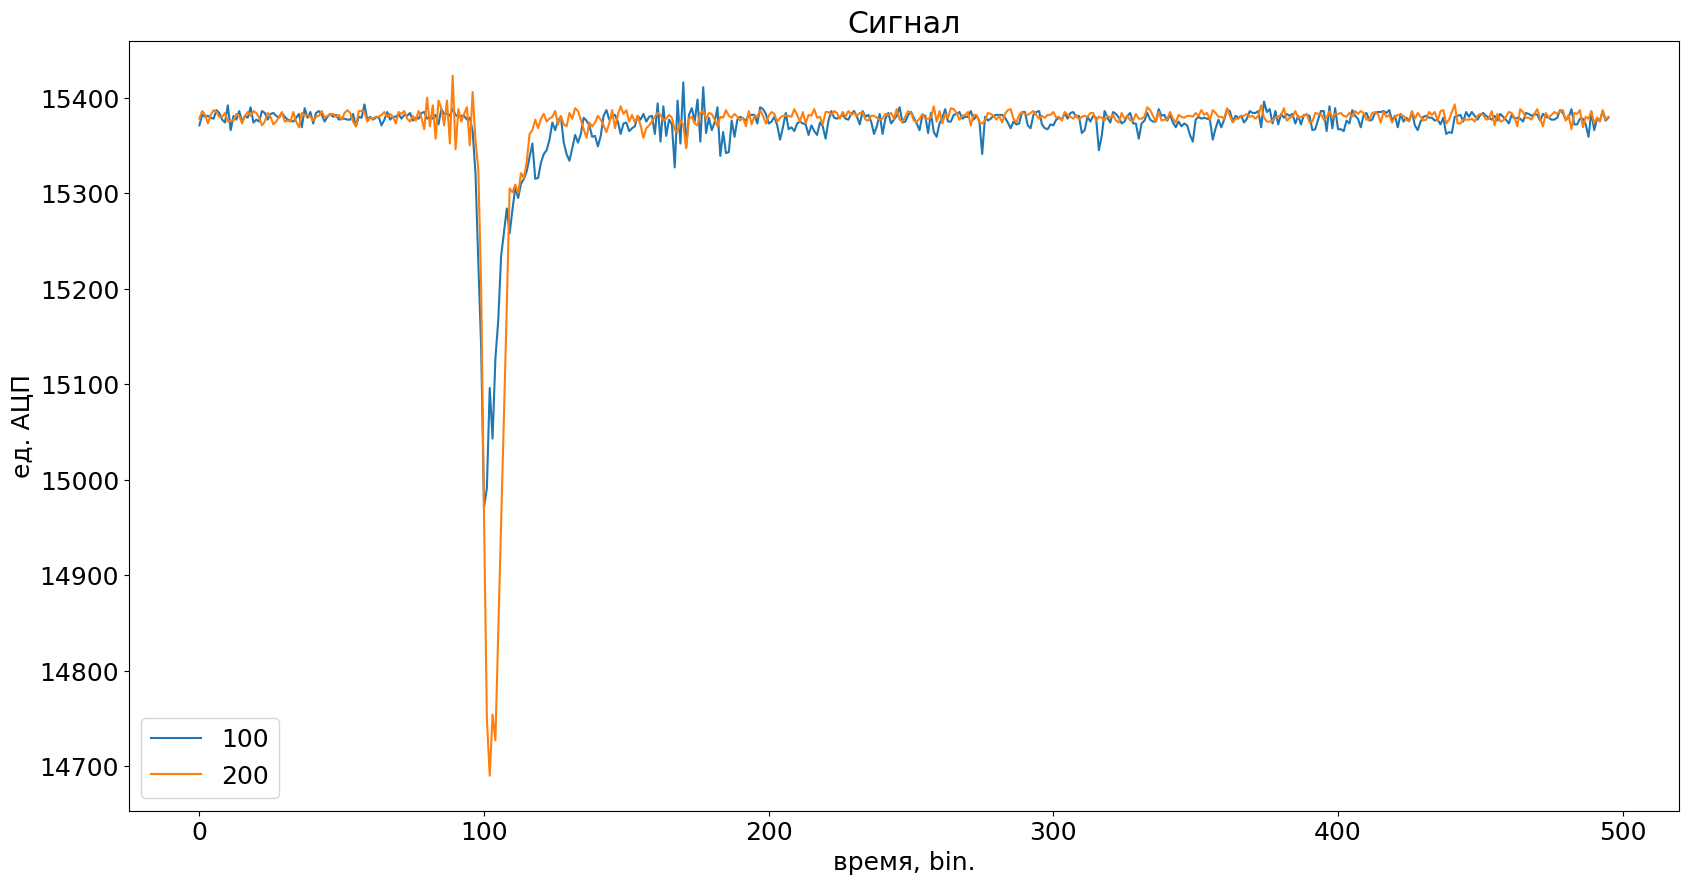

In [ ]:
N=[100,200]
ax = df.T[N].plot(title='Сигнал' ,figsize=(20,10))
plt.rcParams.update({'font.size': fs})
ax.set_xlabel("время, bin.")
ax.set_ylabel("ед. АЦП")
ax.set_title('Сигнал')

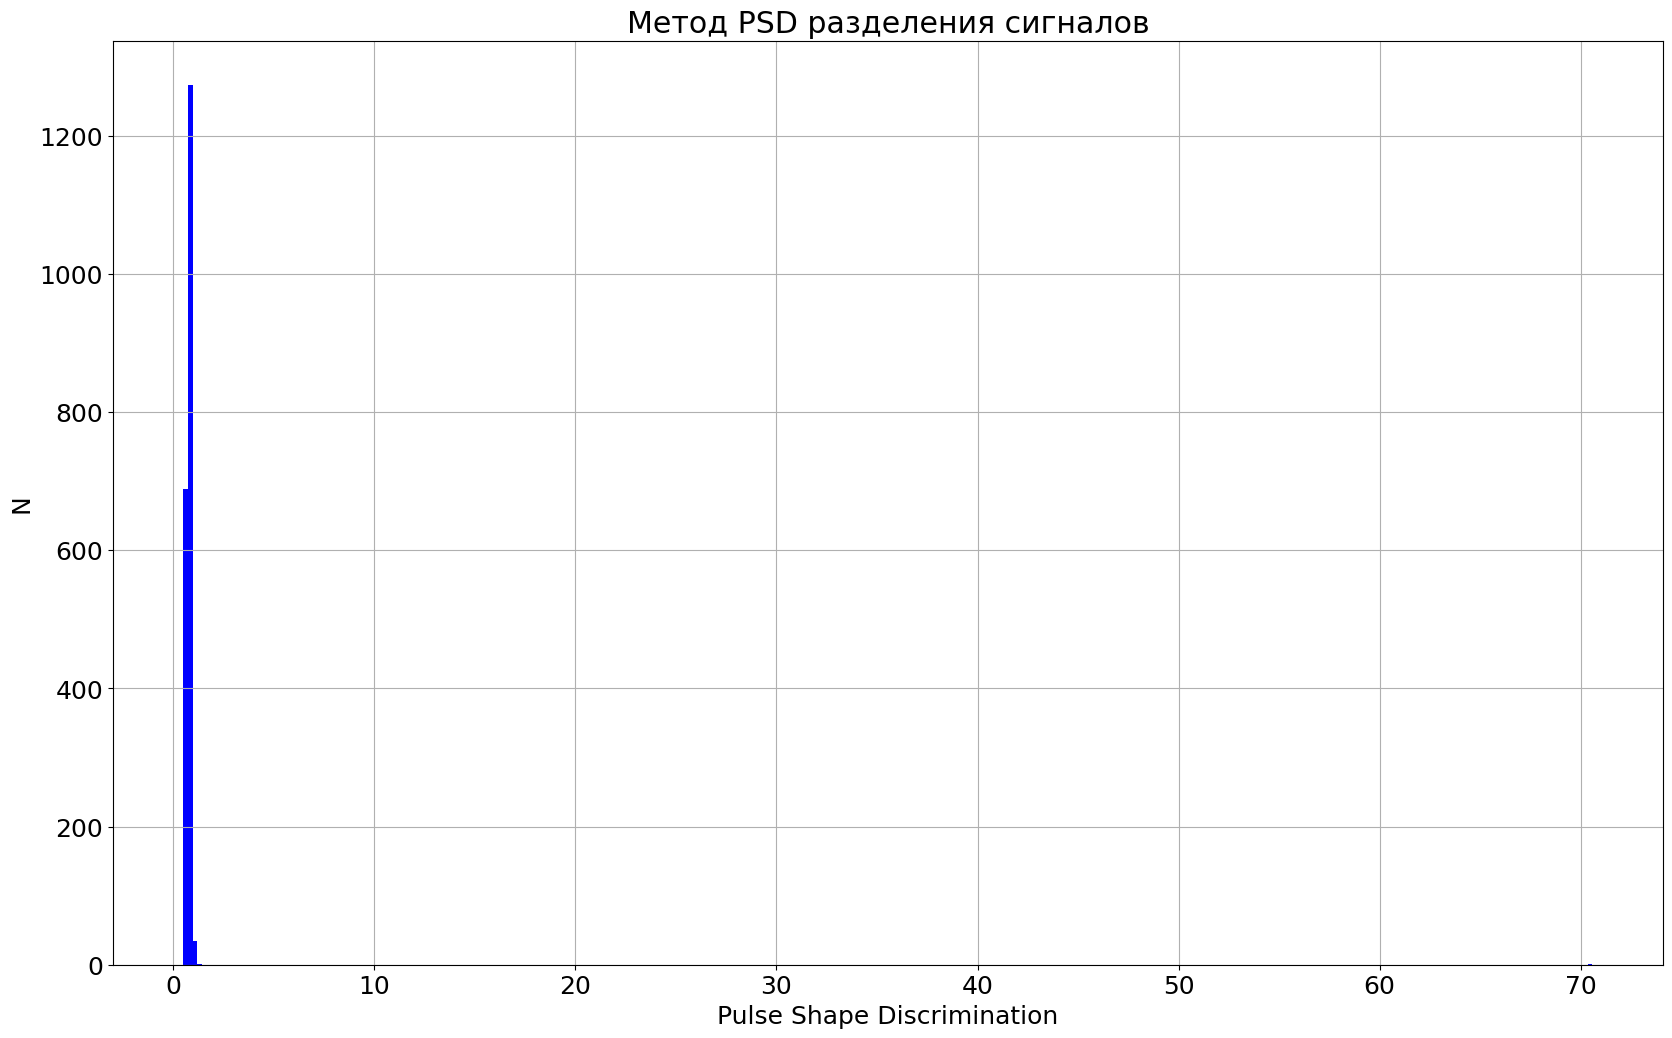

In [ ]:
fig, ax = plt.subplots()
dec=0;
N=PSD.shape[0]
tmp=np.sort(PSD)
ax.hist(tmp[int(N*dec):int(N*(1-dec))],300,color='blue');
ax.set_xlabel("Pulse Shape Discrimination")
ax.set_ylabel("N")
ax.set_title('Метод PSD разделения сигналов')# до преминения фильтра
ax.grid()